# 1. Analisi Statistica degli Stipendi

### 1.1 Definizione dei Dati

In [ ]:
# Definizione della lista degli stipendi
stipendi = [3000, 4000, 2500, 5000, 4000, 3500]
print("Stipendi caricati:", stipendi)

### 1.2 Calcolo di Minimo e Massimo

In [ ]:
# Calcolo del valore minimo e massimo
minimo = min(stipendi)
massimo = max(stipendi)

print("Minimo:", minimo)
print("Massimo:", massimo)

### 1.3 Calcolo della Media

In [ ]:
# Calcolo della media aritmetica
media = sum(stipendi) / len(stipendi)

print("Media:", media)

### 1.4 Calcolo della Mediana

In [ ]:
# Ordinamento dei dati e calcolo della mediana
stipendi_ordinati = sorted(stipendi)
n = len(stipendi_ordinati)

if n % 2 == 0:
    mediana = (stipendi_ordinati[n // 2 - 1] + stipendi_ordinati[n // 2]) / 2
else:
    mediana = stipendi_ordinati[n // 2]

print("Stipendi ordinati:", stipendi_ordinati)
print("Mediana:", mediana)

### 1.5 Calcolo della Moda

In [ ]:
# Calcolo della frequenza e della moda
frequenze = {}
for s in stipendi:
    frequenze[s] = frequenze.get(s, 0) + 1

moda = max(frequenze, key=frequenze.get)

print("Moda:", moda)

# 2. Processo di Normalizzazione dei Dati (Min-Max)

### 2.1 Inizializzazione dei Dataset Originali

In [ ]:
# Definizione delle liste dati originali per i test di scaling e ridondanza
eta = [22, 28, 35, 45, 52, 30, 40, 25]
stipendio = [1800, 2200, 3500, 5000, 7000, 2800, 4500, 2000]
esperienza = [1, 3, 8, 18, 25, 5, 14, 2]

print("Dati per la normalizzazione caricati con successo.")

### 2.2 Definizione della Funzione Min-Max

In [ ]:
# Funzione di normalizzazione Min-Max
def normalizza_minmax(lista):
    minimo = min(lista)
    massimo = max(lista)
    rango = massimo - minimo
    
    if rango == 0:
        return [0.5 for _ in lista]
        
    risultato = []
    for x in lista:
        x_norm = (x - minimo) / rango
        risultato.append(round(x_norm, 4))
        
    return risultato

### 2.3 Analisi Matematica e Calcolo Passo-Passo (Esempio: Età)

In [ ]:
# Esempio pratico di calcolo passo-passo con formattazione tabellare
minimo = min(eta)
massimo = max(eta)
rango = massimo - minimo

print(f"Età minima  : {minimo}")
print(f"Età massima : {massimo}")
print(f"Rango       : {rango}\n")

print(f"{'Età orig':10} {'Calcolo':30} {'Risultato':10}")
print("-" * 52)

for x in eta:
    risultato = (x - minimo) / rango
    calcolo = f"({x} - {minimo}) / {rango}"
    print(f"{x:10} {calcolo:30} {risultato:.4f}")

### 2.4 Esecuzione della Normalizzazione su tutte le Feature

In [ ]:
# Normalizzazione effettiva di tutte le feature tramite la funzione
eta_norm = normalizza_minmax(eta)
stipendio_norm = normalizza_minmax(stipendio)
esperienza_norm = normalizza_minmax(esperienza)

print("Normalizzazione completata.")

### 2.5 Validazione e Confronto dei Risultati Finali

In [ ]:
# Stampa dei risultati finali per il confronto
print("Età Normalizzata:", eta_norm)
print("Stipendio Normalizzato:", stipendio_norm)
print("Esperienza Normalizzata:", esperienza_norm)

# 3. Analisi della Ridondanza e Selezione delle Variabili

### 3.1 Caricamento del Dataset Antropometrico

In [ ]:
# Definizione delle variabili antropometriche
persone = ["Alice", "Bruno", "Carla", "Davide", "Elena"]
altezza      = [160, 175, 168, 180, 155]
peso         = [55, 80, 65, 85, 50]
circ_vita    = [65, 90, 75, 95, 60]
circ_fianchi = [88, 105, 95, 108, 85]
imc          = [21, 26, 23, 26, 21]

print(f"{'Persona':10} {'Altezza':8} {'Peso':6} {'C.Vita':8} {'C.Fianchi':10} {'IMC':5}")
print("-" * 55)

for i, p in enumerate(persone):
    print(f"{p:10} {altezza[i]:<8} {peso[i]:<6} {circ_vita[i]:<8} {circ_fianchi[i]:<10} {imc[i]:<5}")

### 3.2 Calcolo della Media e della Covarianza

In [ ]:
def calcola_media_rid(lista):
    return sum(lista) / len(lista)

def calcola_covarianza(x, y):
    n = len(x)
    media_x = calcola_media_rid(x)
    media_y = calcola_media_rid(y)
    
    somma_prodotti = 0
    for i in range(n):
        somma_prodotti += ((x[i] - media_x) * (y[i] - media_y))
        
    return somma_prodotti / (n - 1)

# Test rapido della covarianza tra altezza e peso
cov_alt_peso = calcola_covarianza(altezza, peso)
print(f"Covarianza tra Altezza e Peso: {cov_alt_peso:.2f}")

### 3.3 Calcolo della Matrice di Correlazione di Pearson

In [ ]:
variabili = {
    "altezza":              altezza,
    "peso":                 peso,
    "circ_vita":            circ_vita,
    "circ_fianchi":         circ_fianchi,
    "imc":                  imc
}

nomi_var = list(variabili.keys())

def calcola_correlazione(x, y):
    # Sfruttiamo la covarianza appena definita sopra
    cov = calcola_covarianza(x, y)
    
    media_x = calcola_media_rid(x)
    media_y = calcola_media_rid(y)
    
    denom_x = sum((xi - media_x) ** 2 for xi in x) ** 0.5
    denom_y = sum((yi - media_y) ** 2 for yi in y) ** 0.5
    
    # Riconduzione al calcolo standard di r
    n = len(x)
    numeratore = cov * (n - 1)
    
    if denom_x == 0 or denom_y == 0:
        return 0.0
    
    return round(numeratore / (denom_x * denom_y), 4)

print(f"{'':12}", end="")
for n in nomi_var:
    print(f"{n:12}", end="")
print()
print("-" * 72)

for n1 in nomi_var:
    print(f"{n1:12}", end="")
    for n2 in nomi_var:
        r = calcola_correlazione(variabili[n1], variabili[n2])
        print(f"{r:12.3f}", end="")
    print()

### 3.4 Filtro delle Feature Altamente Correlate (Feature Selection)

In [ ]:
SOGLIA_CORRELAZIONE = 0.8

da_eliminare = set()
for i, n1 in enumerate(nomi_var):
    for j, n2 in enumerate(nomi_var):
        if i < j:
            r = calcola_correlazione(variabili[n1], variabili[n2])
            if abs(r) > SOGLIA_CORRELAZIONE:
                print(f"    {n1:12} '<->' {n2:12}  : r = {r:3f} --> candidata eliminazione: {n2}")
                da_eliminare.add(n2)

variabili_mantenute = [n for n in nomi_var if n not in da_eliminare]
print(f"\nVariabili eliminate: {sorted(da_eliminare)}")
print(f"Variabili mantenute:  {variabili_mantenute}")

# 4. Processo di Standardizzazione dei Dati (Z-score)

### 4.1 Definizione delle Funzioni Statistiche e di Standardizzazione

In [ ]:
def calcola_media_std(lista):
    return sum(lista) / len(lista)

def calcola_deviazione_standard(lista):
    media = calcola_media_std(lista)
    scarti_quadrati = [(x - media) ** 2 for x in lista]
    varianza = sum(scarti_quadrati) / (len(lista) - 1)
    return varianza ** 0.5

def standardizza_zscore(lista):
    media = calcola_media_std(lista)
    sigma = calcola_deviazione_standard(lista)
    
    if sigma == 0:
        return [0.0 for _ in lista]
        
    risultato = []
    for x in lista:
        z = (x - media) / sigma
        risultato.append(round(z, 4))
        
    return risultato

### 4.2 Analisi Matematica e Calcolo Passo-Passo (Esempio: Dataset Stipendio)

In [ ]:
# Calcolo dei parametri sulla variabile stipendio (riutilizzando la lista caricata nella sezione 2.1)
media_stipendio = calcola_media_std(stipendio)
sigma_stipendio = calcola_deviazione_standard(stipendio)

print(f"Media stipendio        : {media_stipendio:.2f} €")
print(f"Deviazione standard    : {sigma_stipendio:.2f} €\n")

print(f"{'Stipendio':12} {'Calcolo':35} {'Z-score':10}")
print("-" * 65)

for x in stipendio:
    z = (x - media_stipendio) / sigma_stipendio
    calcolo = f"({x} - {media_stipendio:.0f}) / {sigma_stipendio:.0f}"
    interpretazione = "sopra media" if z > 0 else "sotto media"
    print(f"{x:12} {calcolo:35} {z:+.4f}  ({interpretazione})")

### 4.3 Esecuzione della Standardizzazione e Validazione Finale

In [ ]:
# Applicazione dello Z-score a tutte le feature del primo dataset
eta_zscore = standardizza_zscore(eta)
stipendio_zscore = standardizza_zscore(stipendio)
esperienza_zscore = standardizza_zscore(esperienza)

print("Z-score calcolato per tutte le feature.\n")
print("Età Standardizzata:", eta_zscore)
print("Stipendio Standardizzato:", stipendio_zscore)
print("Esperienza Standardizzata:", esperienza_zscore)

## Ridondanza

In [2]:
persone = ["Alice", "Bruno", "Carla", "Davide", "Elena"]
altezza      = [160, 175, 168, 180, 155]
peso         = [55, 80, 65, 85, 50]
circ_vita    = [65, 90, 75, 95, 60]
circ_fianchi = [88, 105, 95, 108, 85]
imc          = [21, 26, 23, 26, 21]

print(f"{'Persona':10} {'Altezza':8} {'Peso':6} {'C.Vita':8} {'C.Fianchi':10} {'IMC':5}")
print("-" * 55)

for i, p in enumerate(persone):
    print(f"{p:10} {altezza[i]:<8} {peso[i]:<6} {circ_vita[i]:<8} {circ_fianchi[i]:<10} {imc[i]:<5}")


Persona    Altezza  Peso   C.Vita   C.Fianchi  IMC  
-------------------------------------------------------
Alice      160      55     65       88         21   
Bruno      175      80     90       105        26   
Carla      168      65     75       95         23   
Davide     180      85     95       108        26   
Elena      155      50     60       85         21   


## Calcolo Manuale Correlazione

In [7]:
variabili = {
    "altezza":              altezza,
    "peso":                 peso,
    "circ_vita":            circ_vita,
    "circ_fianchi":         circ_fianchi,
    "imc":                  imc
}

nomi_var = list(variabili.keys())

def calcola_media(lista):
    return sum(lista) / len(lista)


def calcola_correlazione(x, y):
    n = len(x)
    media_x = calcola_media(x)
    media_y = calcola_media(y)

    numeratore = sum((x[i] - media_x) * (y[i] - media_y) for i in range(n))
    denom_x    = sum((x[i] - media_x) ** 2 for i in range(n)) ** 0.5
    denom_y    = sum((y[i] - media_y) ** 2 for i in range(n)) ** 0.5

    if denom_x == 0 or denom_y == 0:
        return 0.0
    
    return round(numeratore / (denom_x * denom_y), 4)


print(f"{'':12}", end="")
for n in nomi_var:
    print(f"{n:12}", end="")
print()
print("-" * 72)

for n1 in nomi_var:
    print(f"{n1:12}", end="")
    for n2 in nomi_var:
        r = calcola_correlazione(variabili[n1], variabili[n2])
        print(f"{r:12.3f}", end="")
    print()

            altezza     peso        circ_vita   circ_fianchiimc         
------------------------------------------------------------------------
altezza            1.000       0.992       0.992       0.992       0.964
peso               0.992       1.000       1.000       1.000       0.986
circ_vita          0.992       1.000       1.000       1.000       0.986
circ_fianchi       0.992       1.000       1.000       1.000       0.989
imc                0.964       0.986       0.986       0.989       1.000


## Selezione Basata sulla Correlazione

In [19]:
SOGLIA_CORRELAZIONE = 0.8

da_eliminare = set()
for i, n1 in enumerate(nomi_var):
    for j, n2 in enumerate(nomi_var):
        if i < j:
            r = calcola_correlazione(variabili[n1], variabili[n2])
            if abs(r) > SOGLIA_CORRELAZIONE:
                print(f"    {n1:12} '<->' {n2:12}  : r = {r:3f} --> candidata eliminazione: {n2}")
                da_eliminare.add(n2)

variabili_mantenute = [n for n in nomi_var if n not in da_eliminare]
print(f"\nVariabili eliminate: {sorted(da_eliminare)}")
print(f"Variabili mantenute:  {variabili_mantenute}")

    altezza      '<->' peso          : r = 0.992300 --> candidata eliminazione: peso
    altezza      '<->' circ_vita     : r = 0.992300 --> candidata eliminazione: circ_vita
    altezza      '<->' circ_fianchi  : r = 0.991500 --> candidata eliminazione: circ_fianchi
    altezza      '<->' imc           : r = 0.964100 --> candidata eliminazione: imc
    peso         '<->' circ_vita     : r = 1.000000 --> candidata eliminazione: circ_vita
    peso         '<->' circ_fianchi  : r = 0.999800 --> candidata eliminazione: circ_fianchi
    peso         '<->' imc           : r = 0.986400 --> candidata eliminazione: imc
    circ_vita    '<->' circ_fianchi  : r = 0.999800 --> candidata eliminazione: circ_fianchi
    circ_vita    '<->' imc           : r = 0.986400 --> candidata eliminazione: imc
    circ_fianchi '<->' imc           : r = 0.988700 --> candidata eliminazione: imc

Variabili eliminate: ['circ_fianchi', 'circ_vita', 'imc', 'peso']
Variabili mantenute:  ['altezza']


# Funzione Covarianza

In [18]:
persone = ["Alice", "Bruno", "Carla", "Davide", "Elena"]
altezza      = [160, 175, 168, 180, 155]
peso         = [55, 80, 65, 85, 50]
circ_vita    = [65, 90, 75, 95, 60]
circ_fianchi = [88, 105, 95, 108, 85]
imc          = [21, 26, 23, 26, 21]

def calcola_covarianza(x,y):

    n = len(x)

    media_x = calcola_media(x)
    media_y = calcola_media(y)
    
    somma_prodotti = 0

    for i in range(n):

        somma_prodotti += (
            (x[i] - media_x) * (y[i] - media_y)
        )
    return somma_prodotti / (n - 1)


## Dati standaridizzati

In [ ]:
# Dati Standardizzati
#====================

dati_z = [
    altezza_z,
    peso_z, 
    vita_z,
    fianchi_z, 
    imc_z 
]


# nomi da stampare

nomi_variabili = [
    "altezza",
    "peso",
    "circ_fianchi",
    "circ_vita",
    "imc"
]

n_var = len(dati_z)

## Costruzione matrice di covarianza

In [16]:
matrice_cov = []

for i in range(n_var):
    riga = []

    for j in range(n_var):
        cov = calcola_covarianza(
            dati_z[i],
            dati_z[j]
        )
    riga.append(round(cov, 4))

matrice_cov.append(riga)

## Stampa Matrice

In [15]:
print("Matrice di Covarianza\n")

for nome, riga in zip(
    nomi_variabili,
    matrice_cov
):
    print(
        f"{nome:10}",
        riga
    )

Matrice di Covarianza

altezza    [1.0, 0.9923, 0.9923, 0.9915, 0.9641]
peso       [0.9923, 1.0, 1.0, 0.9998, 0.9864]
circ_vita  [0.9923, 1.0, 1.0, 0.9998, 0.9864]
circ_fianchi [0.9915, 0.9998, 0.9998, 1.0, 0.9887]
imc        [0.9641, 0.9864, 0.9864, 0.9887, 1.0]


## Eserizio Covarianza tutto insime

In [14]:
# 1. DATI DI PARTENZA
persone = ["Alice", "Bruno", "Carla", "Davide", "Elena"]
altezza      = [160, 175, 168, 180, 155]
peso         = [55, 80, 65, 85, 50]
circ_vita    = [65, 90, 75, 95, 60]
circ_fianchi = [88, 105, 95, 108, 85]
imc          = [21, 26, 23, 26, 21]

# 2. FUNZIONI DI CALCOLO
def calcola_media(lista):
    return sum(lista) / len(lista)

def calcola_deviazione_standard(lista, media):
    varianza = sum((x - media) ** 2 for x in lista) / (len(lista) - 1)
    return varianza ** 0.5

def standardizza(lista):
    media = calcola_media(lista)
    dev_std = calcola_deviazione_standard(lista, media)
    return [(x - media) / dev_std for x in lista]

def calcola_covarianza(x, y):
    n = len(x)
    media_x = calcola_media(x)
    media_y = calcola_media(y)
    
    somma_prodotti = 0
    for i in range(n):
        somma_prodotti += (x[i] - media_x) * (y[i] - media_y)
        
    return somma_prodotti / (n - 1)

# 3. CREAZIONE DATI STANDARDIZZATI (Z-SCORE)
altezza_z = standardizza(altezza)
peso_z = standardizza(peso)
vita_z = standardizza(circ_vita)
fianchi_z = standardizza(circ_fianchi)
imc_z = standardizza(imc)

dati_z = [
    altezza_z,
    peso_z, 
    vita_z,
    fianchi_z, 
    imc_z 
]

# Nomi delle variabili (con le virgole!)
nomi_variabili = [
    "altezza",
    "peso",
    "circ_vita",
    "circ_fianchi",
    "imc"
]

n_var = len(dati_z)

# 4. COSTRUZIONE MATRICE DI COVARIANZA (Indentazione corretta)
matrice_cov = []

for i in range(n_var):
    riga = []
    for j in range(n_var):
        cov = calcola_covarianza(dati_z[i], dati_z[j])
        riga.append(round(cov, 4))
    matrice_cov.append(riga)

# 5. STAMPA DELLA MATRICE DELLA COVARIANZA
print("Matrice di Covarianza (su dati standardizzati):\n")

# Intestazione colonne per renderla più leggibile
print(f"{'':15}", "".join(f"{nome:>15}" for nome in nomi_variabili))
print("-" * 95)

# Righe della matrice
for nome, riga in zip(nomi_variabili, matrice_cov):
    valori_formattati = "".join(f"{valore:15.4f}" for valore in riga)
    print(f"{nome:15} {valori_formattati}")

Matrice di Covarianza (su dati standardizzati):

                        altezza           peso      circ_vita   circ_fianchi            imc
-----------------------------------------------------------------------------------------------
altezza                  1.0000         0.9923         0.9923         0.9915         0.9641
peso                     0.9923         1.0000         1.0000         0.9998         0.9864
circ_vita                0.9923         1.0000         1.0000         0.9998         0.9864
circ_fianchi             0.9915         0.9998         0.9998         1.0000         0.9887
imc                      0.9641         0.9864         0.9864         0.9887         1.0000


# Librerie Time e Numpy con Esericizi

In [20]:
import time 
import numpy as np

n = 1_000_000
lista_a = list(range(n))
lista_b = list(range(n))

start = time.time()
risultato_lista = [a + b for a, b in zip(lista_a, lista_b)]
tempo_lista = time.time() - start


In [21]:
import time
import numpy as np

n = 1_000_000
array_a = np.arange(n)
array_b = np.arange(n)

start = time.time()
risultato_numpy = array_a + array_b
tempo_numpy = time.time() - start 

print(f"tempo senza numpy {tempo_lista}")
print(f"tempo con numpy {tempo_numpy}")
print(f"Numpy è : {tempo_lista - tempo_numpy} secondi più veloce")



tempo senza numpy 0.028650522232055664
tempo con numpy 0.0010600090026855469
Numpy è : 0.027590513229370117 secondi più veloce


In [22]:
import numpy as np
lista_mista = [1, "ciao", 3.5, True]
array_numeri = np.array([1, 2, 3, 4])

print(f"Lista Python        : {lista_mista}")
print(f"Array Numpy         : {array_numeri}")
print()

print(f"Tipo elementi (dtype)   : {array_numeri.dtype}")
print(f"Forma (shape)           : {array_numeri.shape}")
print(f"N dimensioni (ndim)     : {array_numeri.ndim}")
print(f"N totale elementi       : {array_numeri.size}")
print(f"Memoria occpuata        : {array_numeri.nbytes} bytes")

Lista Python        : [1, 'ciao', 3.5, True]
Array Numpy         : [1 2 3 4]

Tipo elementi (dtype)   : int64
Forma (shape)           : (4,)
N dimensioni (ndim)     : 1
N totale elementi       : 4
Memoria occpuata        : 32 bytes


## Operazioni vettoriali

### creazione della lista 

In [23]:
a1 = np.array([10, 20, 30, 40, 50])
print(a1)

[10 20 30 40 50]


### Arange

In [24]:
a2 = np.arange(0, 10, 2)
print(a2)

[0 2 4 6 8]


### Linspace:

In [25]:
a3 = np.linspace(0, 1, 5)
print(a3)

[0.   0.25 0.5  0.75 1.  ]


### Array di zeri

In [26]:
a4 = np.zeros(5)
print(a4)

[0. 0. 0. 0. 0.]


### Matrice di 1

In [27]:
a5 = np.ones((2, 3))
print(a5)

[[1. 1. 1.]
 [1. 1. 1.]]


### Matrice d'identità

In [29]:
e = np.eye(3)
print(e)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### Numeri casuali unformi

In [30]:
r = np.random.rand(3,3)
print(r)

[[0.52913383 0.22470445 0.7547139 ]
 [0.74503789 0.73789155 0.56817703]
 [0.47041786 0.474346   0.85988596]]


### Caasuali normali

In [31]:
z = np.zeros(5)
print(z)

[0. 0. 0. 0. 0.]


# Array

## Operazioni con gli Array

In [32]:
import numpy as np

stipendi = np.array([2000, 2500, 3000, 3500, 4000])

## Operazioni statistiche fondamentali

In [33]:
dati = np.array([15, 22, 18, 30, 25, 19, 28, 22, 17, 26])

print("=== STATISTICHE ARRAY ===")
print(f"Media         : {np.mean(dati):.2f}")
print(f"Mediana       : {np.median(dati):.2f}")
print(f"Dev. standard : {np.std(dati):.2f}")
print(f"Varianza      : {np.var(dati):.2f}")
print(f"Minimo        : {np.min(dati)} (indice: {np.argmin(dati)})")
print(f"Massimo       : {np.max(dati)} (indice: {np.argmax(dati)})")
print(f"Somma         : {np.sum(dati)}")
print(f"Percentile 25 : {np.percentile(dati, 25)}")
print(f"Percentile 75 : {np.percentile(dati, 75)}")
print(f"IQR           : {np.percentile(dati, 75) - np.percentile(dati, 25)}")

=== STATISTICHE ARRAY ===
Media         : 22.20
Mediana       : 22.00
Dev. standard : 4.73
Varianza      : 22.36
Minimo        : 15 (indice: 0)
Massimo       : 30 (indice: 3)
Somma         : 222
Percentile 25 : 18.25
Percentile 75 : 25.75
IQR           : 7.5


## Index Slicing

In [ ]:
a = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

print(f"Primo elemento    : {a[0]}")
print(f"Ultimo elemento   : {a[-1]}")
print(f"Terzo elemento    : {a[2]}")

# Slicing [start:stop:step]
print(f"Primi 4           : {a[:4]}")
print(f"Ultimi 3          : {a[-3:]}")
print(f"Dal 2° al 7°      : {a[1:7]}")
print(f"Step 2            : {a[::2]}")
print(f"Invertito         : {a[::-1]}")

# Boolean indexing
filtro = a > 50
print(f"\nMask booleana     : {filtro}")
# print(f"Valori > 50       : {a[filtro]}")

## Array Multidimensionali

In [34]:
M = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

print(f"Shape   :{M.shape}")
print(f"ndim    :{M.ndim}")
print(f"size    :{M.size}")


print(f"\nElemento  [0,0]     = {M[0,0]}")
print(f"Elemento    [1, 2]    = {M[1, 2]}") 
print(f"Elemento    [2, -1]   = {M[2, -1]}")

# selezione di righe e colonne

print(f"\nPrima riga    :{M[0, :]}")
print(f"Terza colonna   :{M[:, 2]}")
print(f"Sottomatrice    :{M[0:2, 1:3]}")


# Operazioni su assi

print(f"\nSomma colonne (axis=0)    : {M.sum(axis=0)}")
print(f"\nSomma righe (axis=1)      : {M.sum(axis=1)}")
print(f"\nMedia Globale             : {M.mean():.2f}")


Shape   :(3, 4)
ndim    :2
size    :12

Elemento  [0,0]     = 1
Elemento    [1, 2]    = 7
Elemento    [2, -1]   = 12

Prima riga    :[1 2 3 4]
Terza colonna   :[ 3  7 11]
Sottomatrice    :[[2 3]
 [6 7]]

Somma colonne (axis=0)    : [15 18 21 24]

Somma righe (axis=1)      : [10 26 42]

Media Globale             : 6.50


## Somma colonne

In [35]:
print(f"\nSomma colonne (axis=0)    : {M.sum(axis=0)}")


Somma colonne (axis=0)    : [15 18 21 24]


## Somma righe

In [ ]:
print(f"\nSomma righe (axis=1)      : {M.sum(axis=1)}")

# Alti comandi Utili

## np.linal.eig

In [36]:
autovalori = [2.2479, 0.0361, 1.0493]

## DataFrame

In [37]:
import pandas as pd
import numpy  as np
data = {
    "nome":      ["Anna", "Luca",    "Marco",   "Sara",  "Giulia"],
    "eta":       [25,       32,        28,        45,       35   ],
    "città":     ["Roma", "Milano", "Roma", "Torino", "Milano"   ],
    "stipendio": [2000,    3500,     2800,    5000,     4200     ],
    "anni_expo": [2,        8,         4,       18,       10     ]
}

df = pd.DataFrame(data)
df.head()

,nome,eta,città,stipendio,anni_expo
0,Anna,25,Roma,2000,2
1,Luca,32,Milano,3500,8
2,Marco,28,Roma,2800,4
3,Sara,45,Torino,5000,18
4,Giulia,35,Milano,4200,10


# Librerie Matplotlib e Seaborn 

## importazioni delle librerie necessarie 

In [1]:
# Importazione di tutte le librerie necessarie per il notebook
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configurazione per mostrare i grafici Matplotlib e Seaborn integrati direttamente nel notebook
%matplotlib inline

print("Librerie caricate con successo!")

Librerie caricate con successo!


## 1. Introduzione a Matplotlib
**Matplotlib** è la libreria di visualizzazione fondamentale di Python su cui sono costruite quasi tutte le altre (Seaborn, Pandas .plot()) 

### Gerarchia degli oggetti:
* **Figure**: rappresenta il foglio di carta o la cornice esterna.
* **Axes**: il pannello grafico completo (il disegno vero e proprio) contenente i titoli, i dati, le legende e la griglia. 

*Attenzione: Axes non indica gli assi X e Y (che si chiamano Axis)*.

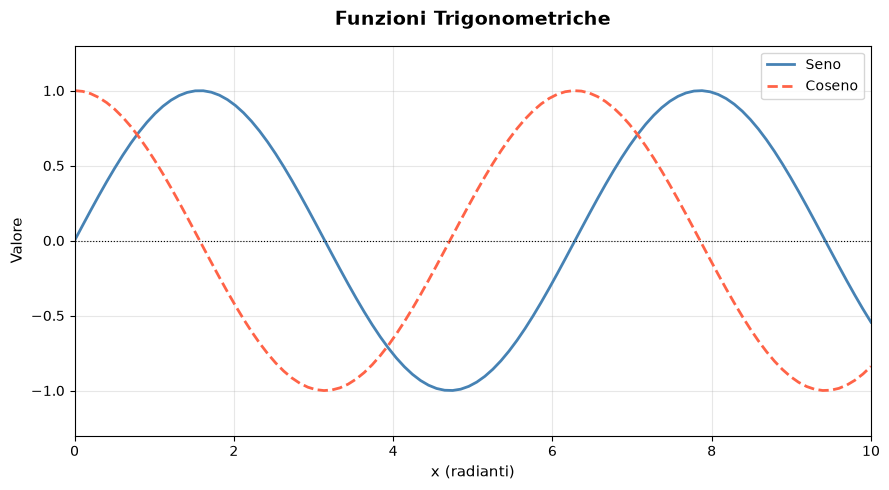

In [2]:
# Creazione di dati matematici fluidi con np.linspace (100 punti tra 0 e 10)
x = np.linspace(0, 10, 100)
y1 = np.sin(x)  # Sfrutta il broadcasting di NumPy
y2 = np.cos(x)

# Creazione standard e professionale tramite plt.subplots()
fig, ax = plt.subplots(figsize=(9, 5)) # Dimensioni in pollici (larghezza, altezza)

# Disegno delle linee con stili personalizzati
ax.plot(x, y1, color="steelblue", linewidth=2, linestyle="-", marker="", label="Seno")
ax.plot(x, y2, color="tomato", linewidth=2, linestyle="--", label="Coseno")

# Personalizzazione del layout e dei dettagli visivi
ax.set_title("Funzioni Trigonometriche", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("x (radianti)", fontsize=11)
ax.set_ylabel("Valore", fontsize=11)

ax.legend(fontsize=10, loc="upper right") # Mostra la legenda usando i label definiti sopra
ax.axhline(0, color="black", linewidth=0.8, linestyle=":") # Linea orizzontale di riferimento sullo 0
ax.grid(True, alpha=0.3) # Attiva la griglia con il 30% di opacità

# Impostazione manuale dei limiti degli assi
ax.set_xlim(0, 10)
ax.set_ylim(-1.3, 1.3)

plt.tight_layout() # Ottimizza i margini per evitare tagli di testo
plt.show()

## 2. Introduzione a Seaborn
**Seaborn** è costruita sopra Matplotlib ed è orientata alle relazioni statistiche[cite: 26].
Gestisce nativamente i **DataFrame Pandas** in **formato Tidy** (o long-format), dove ogni riga è un'osservazione e ogni colonna è una variabile.

**Seaborn offre due tipi di funzioni:**
1. **Axes-level** (es. `sns.histplot()`): disegnano su un oggetto `ax` esistente.
2. **Figure-level** (es. `sns.displot()`): creano in autonomia un'intera figura multi-pannello.

Prime 5 righe del dataset 'tips':
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


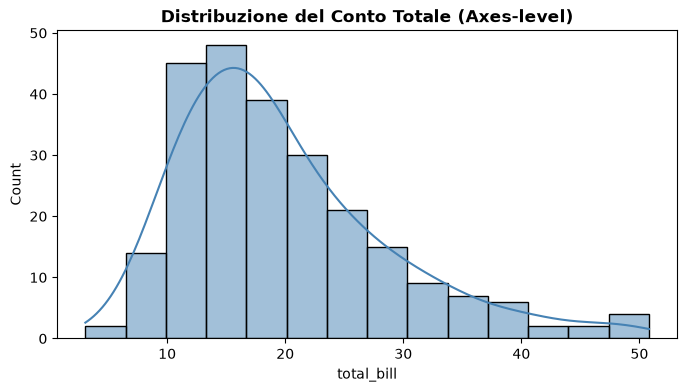

In [3]:
# Caricamento di uno dei dataset integrati di Seaborn per esercitarsi
tips = sns.load_dataset("tips") # Dataset delle mance al ristorante

# Visualizzazione delle prime righe del DataFrame
print("Prime 5 righe del dataset 'tips':")
print(tips.head())

# Creazione di un grafico con funzione Axes-level (Istagroamma)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=tips, x="total_bill", kde=True, color="steelblue", ax=ax)
ax.set_title("Distribuzione del Conto Totale (Axes-level)", fontsize=12, fontweight="bold")
plt.show()

## 3. Introduzione a Plotly

**Plotly** produce grafici **interattivi HTML** che consentono zoom, hover con tooltip ed esportazione direttamente nel browser o all'interno del notebook.

Utilizza due interfacce principali:
* **px (Plotly Express)**: sintassi immediata e configurazioni automatiche adatte per il 70% dei casi[cite: 44, 46].
* **go (Graph Objects)**: permette di costruire e personalizzare il grafico pezzo dopo pezzo[cite: 50].

In [4]:
# Esempio Interattivo con Plotly Express (px)
fig_px = px.scatter(tips, x="total_bill", y="tip", color="sex", 
                    title="Conto vs Mancia (Plotly Express)")
fig_px.show()

# Esempio Interattivo con Plotly Graph Objects (go)
fig_go = go.Figure()
fig_go.add_trace(go.Scatter(x=[1, 2, 3, 4], y=[10, 15, 7, 12], mode='lines+markers', name='Andamento'))
fig_go.update_layout(title="Grafico Personalizzato (Plotly Graph Objects)", xaxis_title="Asse X", yaxis_title="Asse Y")
fig_go.show()

## 4. La Grammatica della Visualizzazione & Grafici di Base

Costruiamo una dashboard multi-pannello (2 righe × 2 colonne) simulando un dataset aziendale composto da 80 dipendenti.

Mostreremo 4 storie diverse dallo stesso dataset:
1. **Istogramma**: per analizzare la distribuzione di una variabile numerica.
2. **Grafico a barre**: per confrontare valori tra categorie distinte.
3. **Grafico lineare**: per osservare l'andamento delle metriche nel tempo.
4. **Scatter plot**: per individuare la relazione e la correlazione tra due variabili numeriche

## Cella di Preparazione Dati (Codice)

Esegui prima questa cella per caricare i dati che verranno usati nei 4 grafici successivi.

1. **Istogramma**: per analizzare la distribuzione di una variabile numerica.
2. **Grafico a barre**: per confrontare valori tra categorie distinte.
3. **Grafico lineare**: per osservare l'andamento delle metriche nel tempo.
4. **Scatter plot**: per individuare la relazione e la correlazione tra due variabili numeriche

In [1]:
# Generazione del dataset aziendale sintetico (80 dipendenti)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_dipendenti = 80
eta = np.random.randint(22, 60, size=n_dipendenti)
stipendio = np.random.normal(3000, 800, size=n_dipendenti)
stipendio = np.clip(stipendio, 1200, None)  # Rimuove valori sotto la soglia minima

mesi_lista = ['Gennaio', 'Febbraio', 'Marzo', 'Aprile', 'Maggio', 'Giugno', 
              'Luglio', 'Agosto', 'Settembre', 'Ottobre', 'Novembre', 'Dicembre']
mese = [mesi_lista[i % 12] for i in range(n_dipendenti)]

citta = (['Napoli'] * 31) + (['Torino'] * 21) + (['Roma'] * 16) + (['Milano'] * 12)
np.random.shuffle(citta)

# Creazione del DataFrame definitivo
df_azienda = pd.DataFrame({'Età': eta, 'Stipendio': stipendio, 'Mese': mese, 'Città': citta})
print("Dataset 'df_azienda' pronto per l'uso!")

Dataset 'df_azienda' pronto per l'uso!


## GRAFICO 1: ISTOGRAMMA (Analisi della Distribuzione)
L'istogramma viene utilizzato per analizzare la distribuzione di una variabile numerica continua. Mostra la frequenza dei valori all'interno di specifici intervalli (chiamati *bins*). In questo esempio visualizziamo come si distribuiscono gli stipendi all'interno dell'azienda.

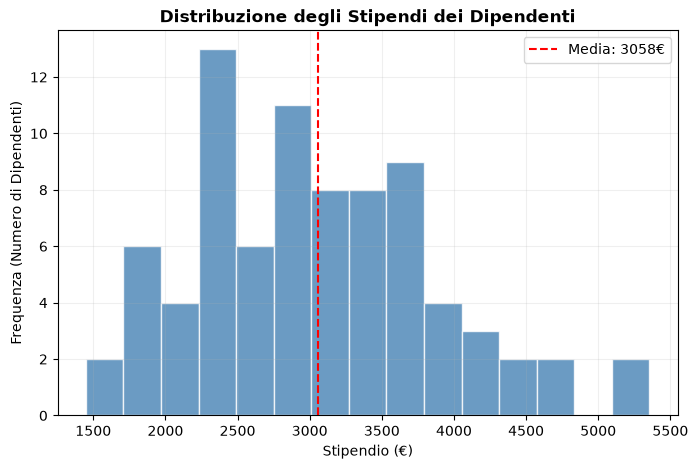

In [2]:
plt.figure(figsize=(8, 5))

# Creazione dell'istogramma
plt.hist(df_azienda['Stipendio'], bins=15, edgecolor="white", color="steelblue", alpha=0.8)

# Calcolo e aggiunta della linea della media
media_stip = df_azienda['Stipendio'].mean()
plt.axvline(media_stip, color="red", linestyle="--", linewidth=1.5, label=f"Media: {media_stip:.0f}€")

# Personalizzazione del grafico
plt.title("Distribuzione degli Stipendi dei Dipendenti", fontsize=12, fontweight="bold")
plt.xlabel("Stipendio (€)")
plt.ylabel("Frequenza (Numero di Dipendenti)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## GRAFICO 2: GRAFICO A BARRE (Confronto tra Categorie)
Il grafico a barre è lo strumento ideale quando si vogliono confrontare valori o conteggi tra categorie discrete e distinte. In questo caso, lo usiamo per visualizzare quanti dipendenti lavorano in ciascuna sede aziendale (Città).

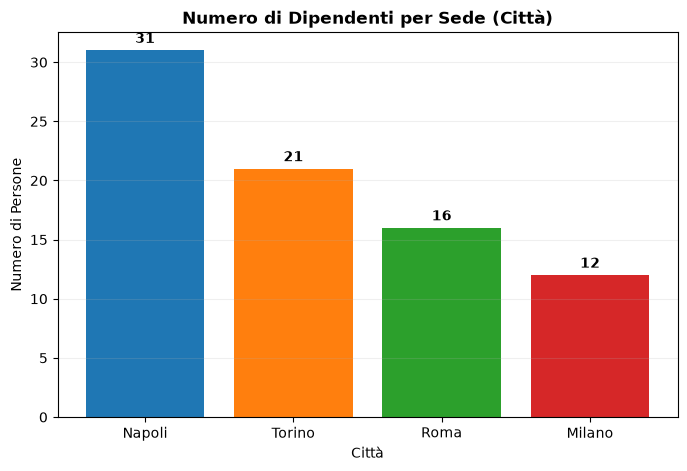

In [3]:
plt.figure(figsize=(8, 5))

# Calcolo delle frequenze per ogni città
conteggio_citta = df_azienda['Città'].value_counts()

# Creazione delle barre con colori differenti
barre = plt.bar(conteggio_citta.index, conteggio_citta.values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

# Aggiunta del valore numerico esatto sopra ogni barra (Etichettatura)
for b in barre:
    h = b.get_height()
    plt.annotate(f'{int(h)}', 
                 xy=(b.get_x() + b.get_width() / 2, h), 
                 xytext=(0, 3), # Spostamento di 3 punti verso l'alto
                 textcoords="offset points", 
                 ha='center', va='bottom', fontweight='bold')

plt.title("Numero di Dipendenti per Sede (Città)", fontsize=12, fontweight="bold")
plt.xlabel("Città")
plt.ylabel("Numero di Persone")
plt.grid(True, axis='y', alpha=0.2)
plt.show()

## GRAFICO 3: GRAFICO LINEARE (Analisi dei Trend Temporali)
Il grafico lineare viene impiegato principalmente per mostrare l'andamento di una o più metriche nel corso del tempo (andamento cronologico). Qui aggreghiamo il budget stipendi per osservare la spesa totale mensile dell'azienda (espressa in migliaia di euro, k€).

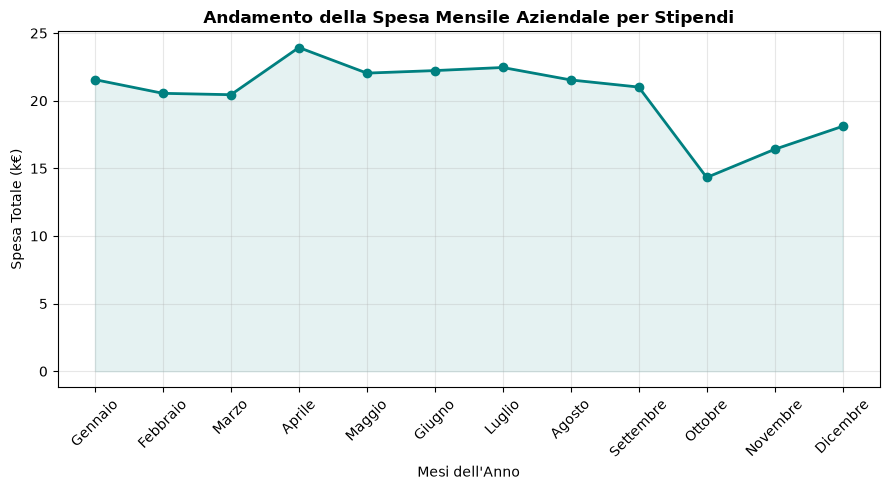

In [4]:
plt.figure(figsize=(9, 5))

# Calcolo della spesa mensile complessiva convertita in k€
somma_mesi = [df_azienda[df_azienda['Mese'] == m]['Stipendio'].sum() / 1000 for m in mesi_lista]

# Disegno della linea e riempimento dell'area sottostante
plt.plot(mesi_lista, somma_mesi, marker="o", markersize=6, color="teal", linewidth=2)
plt.fill_between(mesi_lista, somma_mesi, color="teal", alpha=0.1)

plt.title("Andamento della Spesa Mensile Aziendale per Stipendi", fontsize=12, fontweight="bold")
plt.xlabel("Mesi dell'Anno")
plt.ylabel("Spesa Totale (k€)")
plt.xticks(rotation=45) # Ruota i mesi di 45 gradi per non sovrapporli
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## GRAFICO 4: SCATTER PLOT(Relazione e Correlazione tra Variabili)
Lo scatter plot (o grafico a dispersione) mappa i dati su un piano cartesiano per evidenziare la relazione, la dispersione o l'eventuale livello di correlazione tra due diverse variabili numeriche. In questo grafico mettiamo in relazione l'Età dei dipendenti con il loro Stipendio.

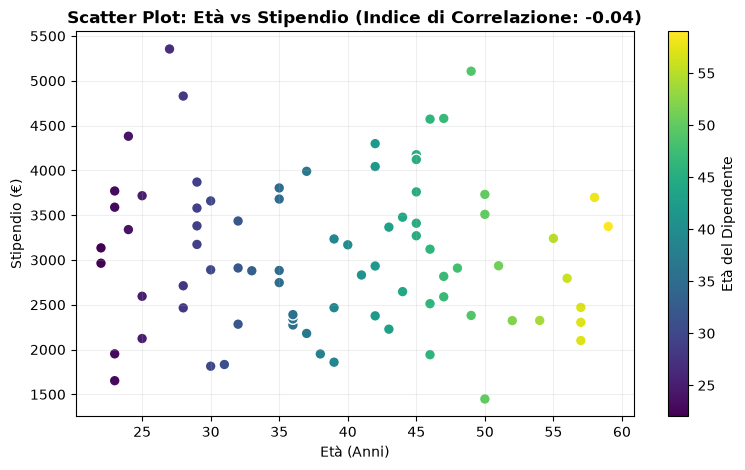

In [5]:
plt.figure(figsize=(9, 5))

# Calcolo del coefficiente di correlazione lineare di Pearson
coeff_corr = df_azienda['Età'].corr(df_azienda['Stipendio'])

# Creazione dello scatter plot (il colore dei punti varia in base all'età)
sc = plt.scatter(df_azienda['Età'], df_azienda['Stipendio'], c=df_azienda['Età'], s=60, cmap="viridis", edgecolor="white")
plt.colorbar(sc, label="Età del Dipendente") # Barra cromatica laterale

plt.title(f"Scatter Plot: Età vs Stipendio (Indice di Correlazione: {coeff_corr:.2f})", fontsize=12, fontweight="bold")
plt.xlabel("Età (Anni)")
plt.ylabel("Stipendio (€)")
plt.grid(True, alpha=0.2)
plt.show()

## 5. Grafici Avanzati

Applichiamo strumenti analitici più avanzati sfruttando l'efficacia visiva di **Seaborn** e **Plotly** sul dataset `tips`:
* **Boxplot**: mette a confronto le distribuzioni evidenziando la mediana, i quartili e i potenziali valori anomali (outlier).
* **Heatmap**: mostra in modo cromatico la matrice di correlazione lineare tra variabili numeriche.
* **Pairplot**: crea una matrice di scatter plot per esplorare incroci multipli e distribuzioni lungo la diagonale.
* **Treemap**: organizza e visualizza dati strutturati in gerarchie rettangolari (Genere -> Giorno -> Fascia oraria)

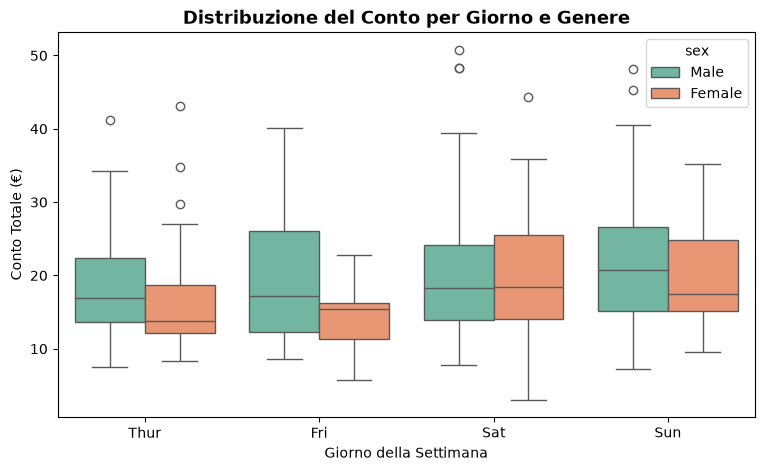

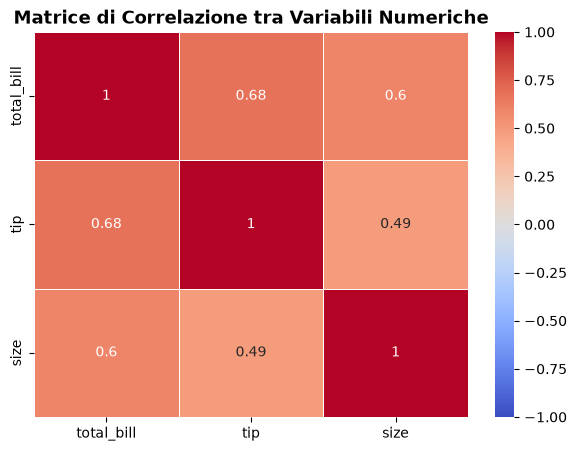

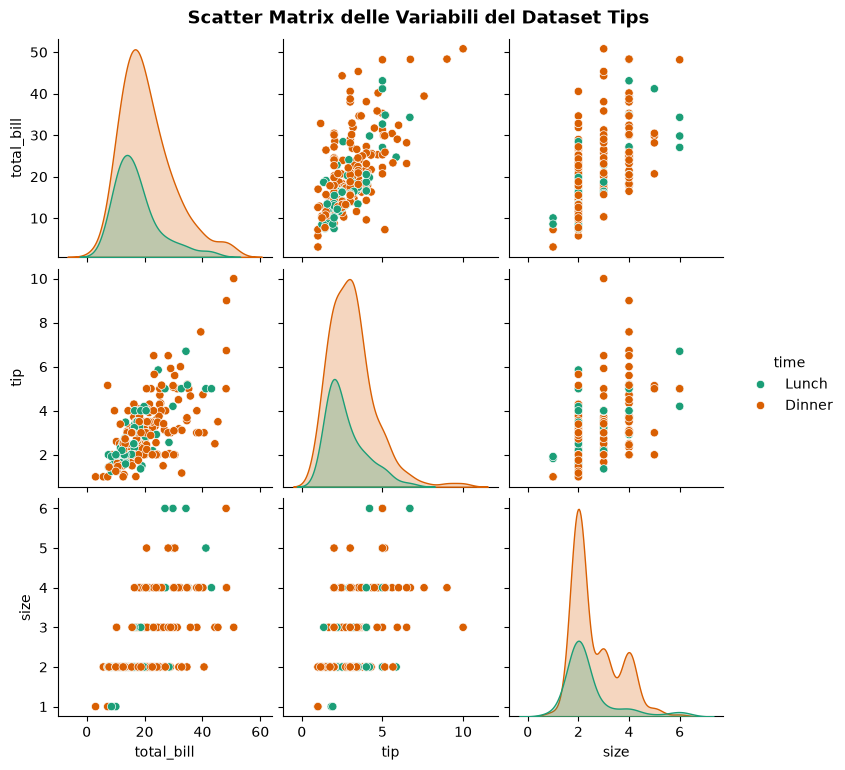

In [6]:
# --- 1. Boxplot (Conto diviso per giorno e genere) ---
plt.figure(figsize=(9, 5))
sns.boxplot(data=tips, x="day", y="total_bill", hue="sex", palette="Set2")
plt.title("Distribuzione del Conto per Giorno e Genere", fontsize=13, fontweight="bold")
plt.xlabel("Giorno della Settimana")
plt.ylabel("Conto Totale (€)")
plt.show()

# --- 2. Heatmap (Matrice di correlazione numerica) ---
plt.figure(figsize=(7, 5))
# Selezioniamo solo le colonne numeriche del dataset
corr_matrix = tips.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice di Correlazione tra Variabili Numeriche", fontsize=13, fontweight="bold")
plt.show()

# --- 3. Pairplot (Matrice di Scatter Plot condizionata dal pranzo/cena) ---
sns.pairplot(data=tips, vars=["total_bill", "tip", "size"], hue="time", palette="Dark2")
plt.suptitle("Scatter Matrix delle Variabili del Dataset Tips", y=1.02, fontsize=13, fontweight="bold")
plt.show()

# --- 4. Treemap Gerarchico (Interattivo con Plotly) ---
fig_tree = px.treemap(tips, path=['sex', 'day', 'time'], values='total_bill',
                      title="Gerarchia Finanziaria dei Conti (Genere -> Giorno -> Fascia)")
# fig_tree.show()

## 6. Esercizio di Fine Modulo: Dataset Titanic

Mettiamo alla prova le competenze acquisite importando il celebre dataset dei passeggeri del **Titanic** per rispondere a 4 domande analitiche fondamentali:
1. Qual è la distribuzione dell'età dei passeggeri? 
2. Quanti passeggeri ci sono all'interno di ciascuna classe? 
3. C'è una relazione visibile tra l'età ed la tariffa del biglietto pagata? 
4. Le tariffe pagate variano sensibilmente in base alla classe di alloggio? 

C:\Users\A1627apulia\AppData\Local\Temp\ipykernel_2272\3439525221.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x="class", ax=axes[0, 1], palette="muted")
C:\Users\A1627apulia\AppData\Local\Temp\ipykernel_2272\3439525221.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x="class", y="fare", ax=axes[1, 1], palette="pastel")


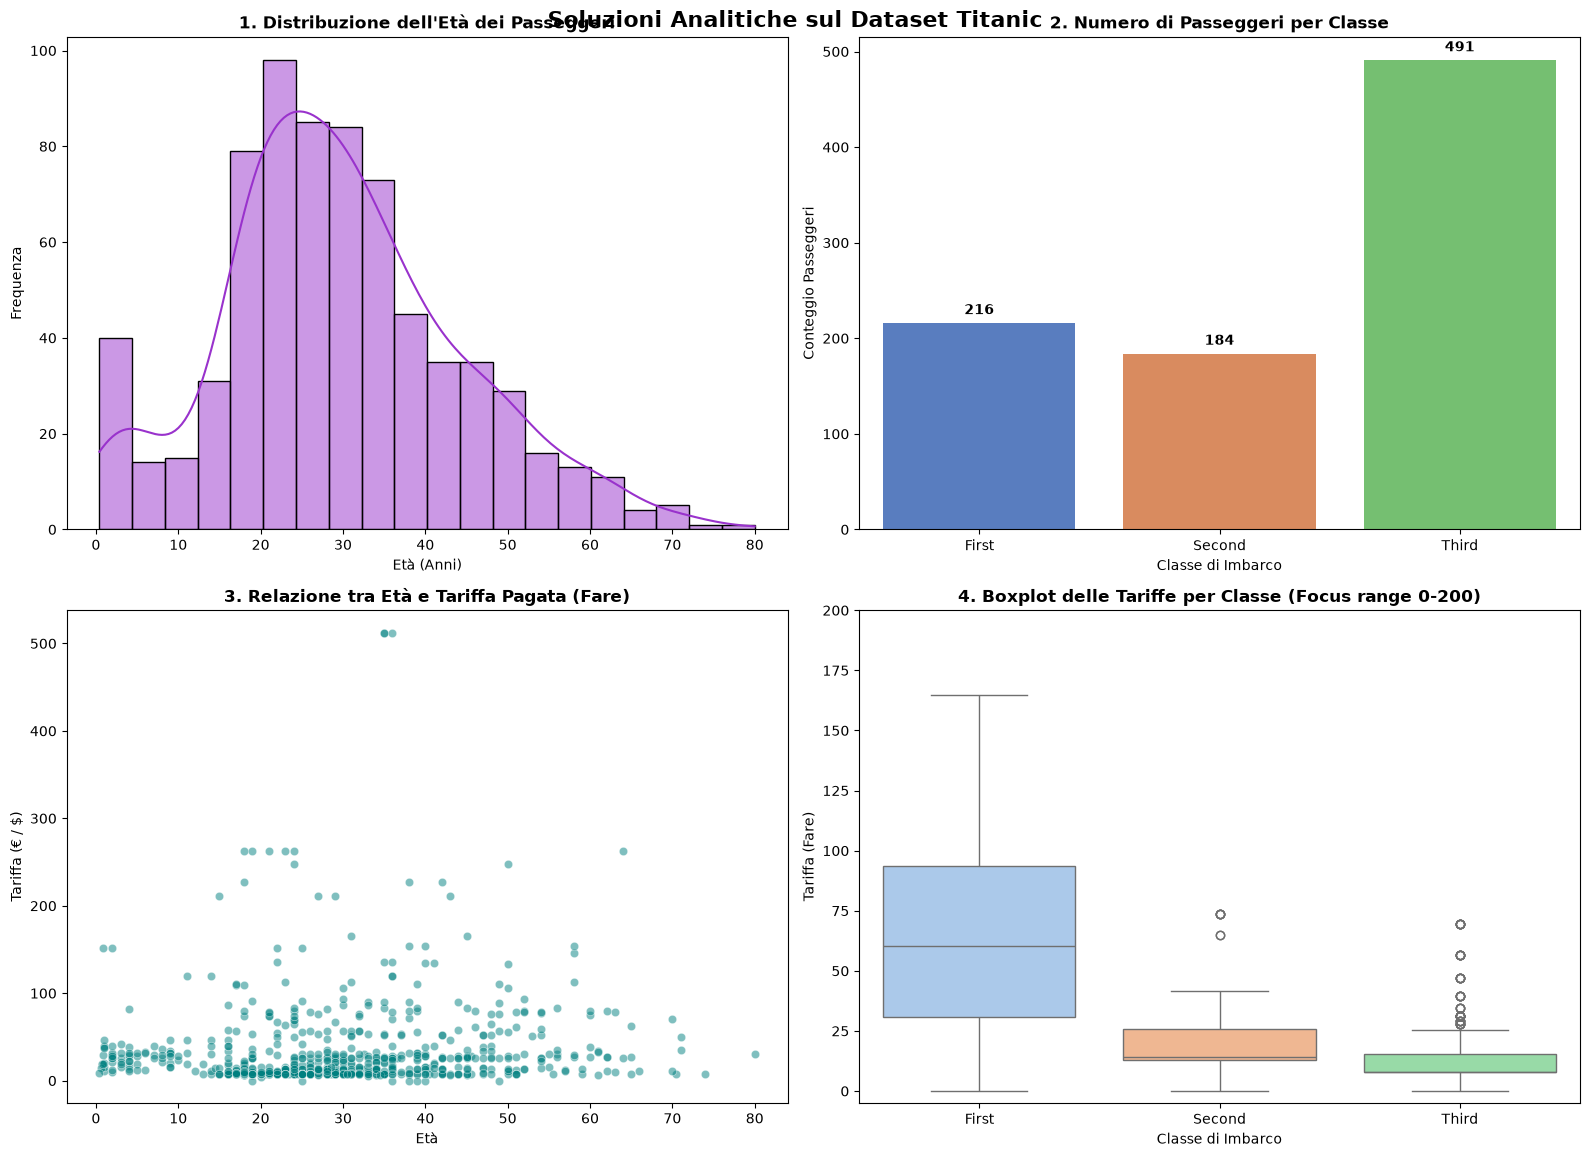

In [7]:
# Caricamento del dataset Titanic integrato in Seaborn
titanic = sns.load_dataset("titanic")

# Apertura di una griglia di visualizzazione 2x2 per raccogliere le soluzioni
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Soluzione Domanda 1: Istogramma dell'età dei passeggeri
sns.histplot(data=titanic, x="age", kde=True, ax=axes[0, 0], color="darkorchid")
axes[0, 0].set_title("1. Distribuzione dell'Età dei Passeggeri", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Età (Anni)")
axes[0, 0].set_ylabel("Frequenza")

# Soluzione Domanda 2: Grafico a Barre (Conteggio passeggeri per classe)
sns.countplot(data=titanic, x="class", ax=axes[0, 1], palette="muted")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold')
axes[0, 1].set_title("2. Numero di Passeggeri per Classe", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Classe di Imbarco")
axes[0, 1].set_ylabel("Conteggio Passeggeri")

# Soluzione Domanda 3: Scatter Plot (Età vs Tariffa di viaggio)
sns.scatterplot(data=titanic, x="age", y="fare", ax=axes[1, 0], alpha=0.5, color="teal")
axes[1, 0].set_title("3. Relazione tra Età e Tariffa Pagata (Fare)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Età")
axes[1, 0].set_ylabel("Tariffa (€ / $)")

# Soluzione Domanda 4: Boxplot (Tariffe pagate suddivise per classe)
sns.boxplot(data=titanic, x="class", y="fare", ax=axes[1, 1], palette="pastel")
# Impostiamo un limite all'asse Y per escludere outlier estremi (es. biglietti > 250) e migliorare la lettura della scatola
axes[1, 1].set_ylim(-5, 200)
axes[1, 1].set_title("4. Boxplot delle Tariffe per Classe (Focus range 0-200)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Classe di Imbarco")
axes[1, 1].set_ylabel("Tariffa (Fare)")

plt.suptitle("Soluzioni Analitiche sul Dataset Titanic", fontsize=16, fontweight="bold", y=0.96)
plt.tight_layout()
plt.show()